In [1]:
# importing libraries
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('https://raw.githubusercontent.com/thamidu02/AIML_project/refs/heads/main/data/balanced_data.csv')

In [3]:
data_df=pd.DataFrame(data)

In [4]:
data_df.head()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,stress_level,target,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
0,-0.516129,0.532513,-0.286205,-0.466182,-0.793095,-0.048494,-0.789323,-0.065063,1.116397,-0.901466,...,0.500000,healthy,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.451613,0.113444,0.428740,0.317736,0.882447,-0.423962,-0.704292,0.462630,-1.300426,0.015120,...,0.500000,healthy,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.193548,0.138622,-0.039458,-0.095566,0.390318,0.780589,0.265728,0.034614,-0.527712,-0.439868,...,0.833333,healthy,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.903226,1.063068,0.538649,-0.046443,0.080632,-1.164706,1.604822,-0.305074,0.264342,-1.125651,...,0.666667,healthy,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.483871,0.117415,0.888653,0.710070,0.229271,0.296010,0.186589,-0.014294,0.462007,-1.840230,...,-0.333333,healthy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
data_df.columns

Index(['age', 'height', 'weight', 'bmi', 'waist_size', 'blood_pressure',
       'glucose', 'heart_rate', 'insulin', 'cholesterol', 'sugar_intake',
       'daily_steps', 'calorie_intake', 'daily_supplement_dosage',
       'water_intake', 'income', 'work_hours', 'sleep_hours',
       'work_sleep_balance', 'stress_level', 'target', 'gender_Female',
       'gender_Male', 'job_type_Healthcare', 'job_type_Labor',
       'job_type_Office', 'job_type_Service', 'job_type_Tech',
       'job_type_Unemployed'],
      dtype='object')

In [6]:
data_df.describe()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,work_sleep_balance,stress_level,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.003823,0.014309,0.032780,0.060644,0.020136,-0.012667,0.047228,-0.032690,-0.005951,0.003951,...,0.127052,0.003833,0.507500,0.492500,0.169500,0.173500,0.158500,0.159500,0.173000,0.166000
std,0.579284,0.744236,0.726317,0.754748,0.748494,0.766680,0.732374,0.808740,0.793466,0.729208,...,0.821018,0.523859,0.500069,0.500069,0.375287,0.378774,0.365301,0.366233,0.378342,0.372174
min,-0.967742,-2.155411,-1.488155,-1.665177,-2.494987,-2.878071,-2.300899,-2.939604,-2.204649,-2.315525,...,-1.997276,-0.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.483871,-0.491521,-0.458288,-0.475792,-0.499730,-0.547553,-0.461426,-0.531622,-0.531502,-0.481871,...,-0.434426,-0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.009024,0.041447,0.040722,0.033636,0.002023,0.050934,-0.012009,0.003476,0.022496,...,0.018831,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.516129,0.504253,0.517436,0.545119,0.538444,0.507939,0.536331,0.473686,0.505658,0.495660,...,0.527461,0.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,2.585270,2.945759,3.127637,2.701138,2.501723,2.434811,2.967024,2.254904,3.201732,...,5.145421,0.833333,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
len(data_df.columns)

29

In [8]:
# splitting the target variable and input data
X,y=data_df.drop('target',axis=1),data_df['target']

In [9]:
data_df.target.value_counts()

,count
target,
healthy,1000
diseased,1000


In [10]:
# encoding the target variable
y=np.where(y=='healthy',1,0)

In [11]:
# splitting into train set and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

## Gradient Boosting

while Random Forest builds many independent trees in parallel,Gradient Boosting builds trees sequentially, where each new tree fixes the errors of the previous ones.

Gradient Boosting learns from its mistakes - each new tree corrects the errors made.

**How Gradient Boosting Works**
1. Begin with a waek model(like a simple decision tree) that gives a rough prediction
2. Calculate how wrong the model was for each data point
3. Build anew decision tree that tries to predict those residuals,it learns how to correct the erros of the prevoius model.
4. Update the overall prediction by adding this new tree's output(sclaed bya learning rate)
5. Repeat this process for many iterations(each adding a small corrective tree). Each new tree gradually improves the model.

**Important parameters**
| Parameter           | Type  | Default          | Description                                                                                                                                         |
| ------------------- | ----- | ---------------- | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`loss`**          | str   | `'log_loss'`     | The loss function to optimize. For classification, `'log_loss'` (logistic regression loss) is common; `'exponential'` gives AdaBoost-like behavior. |
| **`learning_rate`** | float | `0.1`            | Shrinks the contribution of each tree. Smaller values mean slower learning but better generalization. Usually between **0.01 and 0.1**.             |
| **`n_estimators`**  | int   | `100`            | Number of boosting stages (trees). More trees → more accurate, but slower and may overfit.                                                          |
| **`subsample`**     | float | `1.0`            | Fraction of training data used per tree. If < 1.0, adds randomness (reduces overfitting, like in Random Forest). Common range: **0.7–0.9**.         |
| **`criterion`**     | str   | `'friedman_mse'` | Function to measure the quality of a split. `'friedman_mse'` is most commonly used.                                                                 |


In [12]:
# importing the GradientBoostingClassifier from scikit learn
from sklearn.ensemble import GradientBoostingClassifier

In [13]:
param_grid=[
    {
        'learning_rate':[0.1,0.01,0.001,1],
        'n_estimators':[50,80,100]

    }
]

In [14]:
# performanig grid search to find the best parameters
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(GradientBoostingClassifier(random_state=42),param_grid,cv=5)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             param_grid=[{'learning_rate': [0.1, 0.01, 0.001, 1],
                          'n_estimators': [50, 80, 100]}])

In [15]:
print(f"Best cross validation score: {grid_search.best_score_}")

Best cross validation score: 0.509375


In [16]:
print(f"Best paramters: {grid_search.best_params_}")

Best paramters: {'learning_rate': 0.1, 'n_estimators': 50}


In [17]:
results=pd.DataFrame(grid_search.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.487680,0.461912,0.004523,0.001066,0.100,50,"{'learning_rate': 0.1, 'n_estimators': 50}",0.515625,0.493750,0.543750,0.481250,0.512500,0.509375,0.021287,1
1,2.144969,0.878789,0.004278,0.002228,0.100,80,"{'learning_rate': 0.1, 'n_estimators': 80}",0.503125,0.484375,0.509375,0.487500,0.481250,0.493125,0.011075,8
2,1.582897,0.149927,0.002973,0.000424,0.100,100,"{'learning_rate': 0.1, 'n_estimators': 100}",0.534375,0.484375,0.515625,0.478125,0.506250,0.503750,0.020578,3
3,0.727961,0.003105,0.002454,0.000029,0.010,50,"{'learning_rate': 0.01, 'n_estimators': 50}",0.487500,0.493750,0.475000,0.443750,0.475000,0.475000,0.017230,12
4,1.279812,0.141100,0.003141,0.000625,0.010,80,"{'learning_rate': 0.01, 'n_estimators': 80}",0.493750,0.506250,0.496875,0.437500,0.459375,0.478750,0.026026,10
5,1.457898,0.007728,0.002736,0.000066,0.010,100,"{'learning_rate': 0.01, 'n_estimators': 100}",0.484375,0.500000,0.503125,0.440625,0.456250,0.476875,0.024575,11
6,0.856083,0.087873,0.003209,0.000511,0.001,50,"{'learning_rate': 0.001, 'n_estimators': 50}",0.515625,0.512500,0.490625,0.484375,0.475000,0.495625,0.015885,6
7,1.161880,0.007147,0.002754,0.000295,0.001,80,"{'learning_rate': 0.001, 'n_estimators': 80}",0.515625,0.512500,0.490625,0.484375,0.450000,0.490625,0.023635,9
8,1.577416,0.176317,0.003058,0.000577,0.001,100,"{'learning_rate': 0.001, 'n_estimators': 100}",0.518750,0.528125,0.490625,0.487500,0.446875,0.494375,0.028463,7
9,0.726374,0.005353,0.002558,0.000127,1.000,50,"{'learning_rate': 1, 'n_estimators': 50}",0.518750,0.503125,0.468750,0.500000,0.509375,0.500000,0.016887,5


In [19]:
# creating the final model using best pramaters
model=GradientBoostingClassifier(**grid_search.best_params_)
model.fit(X_train,y_train)

GradientBoostingClassifier(n_estimators=50)

In [20]:
print(f"Test score: {model.score(X_test,y_test)}")

Test score: 0.4925


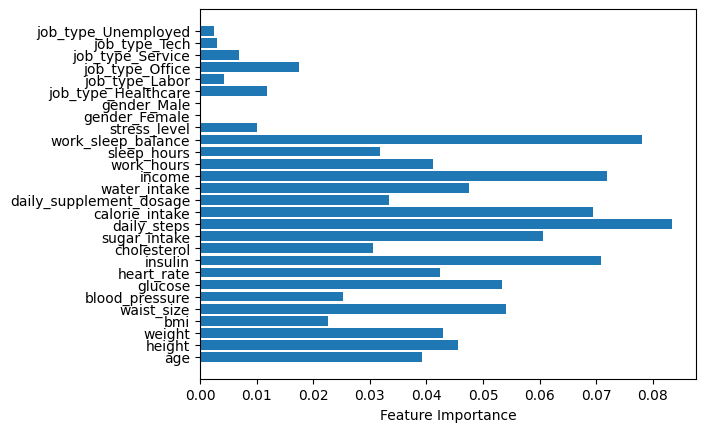

In [21]:
plt.barh(X.columns, model.feature_importances_)
plt.xlabel("Feature Importance")
plt.show()

In [22]:
from sklearn.metrics import classification_report
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.49      0.48      0.49       200
           1       0.49      0.50      0.50       200

    accuracy                           0.49       400
   macro avg       0.49      0.49      0.49       400
weighted avg       0.49      0.49      0.49       400



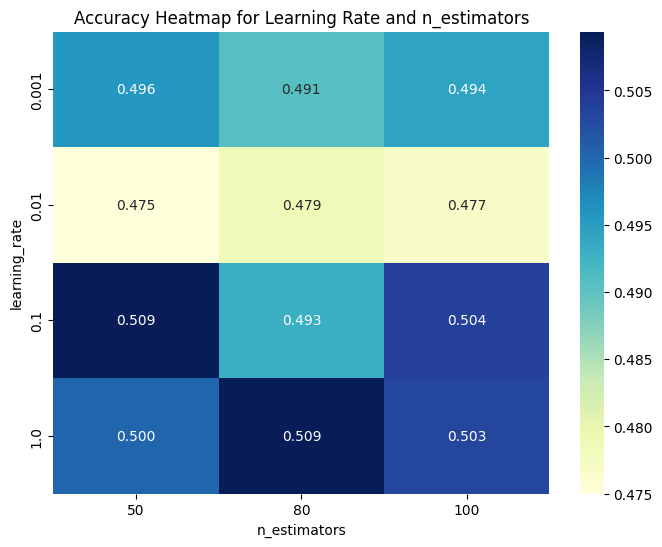

In [23]:
import seaborn as sns

# Reshape the results for the heatmap
heatmap_data = results.pivot(index='param_learning_rate', columns='param_n_estimators', values='mean_test_score')

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title('Accuracy Heatmap for Learning Rate and n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('learning_rate')
plt.show()